# Assignment 1: Housing Price Prediction

IE500618 Machine Learning. Group 4: Emilie, David, Kristian.

We predict `SalePrice` for houses in Ames, Iowa, from `AmesHousing.csv`, and compare three regression models. The notebook follows the six steps in the assignment. The test set is not used before step 6.

## Step 1: Explore and understand the data

**Before we build any models, we have to get to know the data. that's why we look at the columns, the prices, what's missing, what looks wrong, etc.**

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", "{:.1f}".format) # only 1 decimal

RANDOM_STATE = 0 # Same splitting of training and test data

df = pd.read_csv("data/AmesHousing.csv") # One row per house
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


---
### 1a Variables and data types

**The models can only do math on numbers, so we check which columns are text.**

In [107]:
print("Rows, Columns:", df.shape)
print()
print("Columns per data type:")
df.dtypes.value_counts()

Rows, Columns: (2930, 82)

Columns per data type:


str        43
int64      28
float64    11
Name: count, dtype: int64

**So we have 2930 houses and 82 columns. Now to see the names of these columns:**

In [108]:
num_cols = df.select_dtypes(include="number").columns # number columns
print("Numerical columns:", len(num_cols))
num_cols

Numerical columns: 39


Index(['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area',
       'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add',
       'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
       'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd',
       'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area',
       'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch',
       'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold',
       'SalePrice'],
      dtype='str')

In [109]:
text_cols = df.select_dtypes(exclude="number").columns # text columns
print("Text columns:", len(text_cols))
text_cols

Text columns: 43


Index(['MS Zoning', 'Street', 'Alley', 'Lot Shape', 'Land Contour',
       'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1',
       'Condition 2', 'Bldg Type', 'House Style', 'Roof Style', 'Roof Matl',
       'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Exter Qual',
       'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
       'BsmtFin Type 1', 'BsmtFin Type 2', 'Heating', 'Heating QC',
       'Central Air', 'Electrical', 'Kitchen Qual', 'Functional',
       'Fireplace Qu', 'Garage Type', 'Garage Finish', 'Garage Qual',
       'Garage Cond', 'Paved Drive', 'Pool QC', 'Fence', 'Misc Feature',
       'Sale Type', 'Sale Condition'],
      dtype='str')

**But a number column isn't always an amount. A column can have different values for every single house, like an ID:**

In [110]:
# different values per number column, highest first
print("amount of unique numbers in each column:")
df[num_cols].nunique().sort_values(ascending=False).head()

amount of unique numbers in each column:


Order          2930
PID            2930
Lot Area       1960
Gr Liv Area    1292
Bsmt Unf SF    1137
dtype: int64

**`Order` and `PID` have 2930 different values, one for each house. So these are IDs, which also fits with `Order` just counting 1, 2, 3... in `df.head()`.**

---
### 1b Distribution of SalePrice

**`SalePrice` is what we predict, so we look at how it's spread out.**

In [111]:
print("SalePrice statistics:")
df["SalePrice"].describe()

SalePrice statistics:


count     2930.0
mean    180796.1
std      79886.7
min      12789.0
25%     129500.0
50%     160000.0
75%     213500.0
max     755000.0
Name: SalePrice, dtype: float64

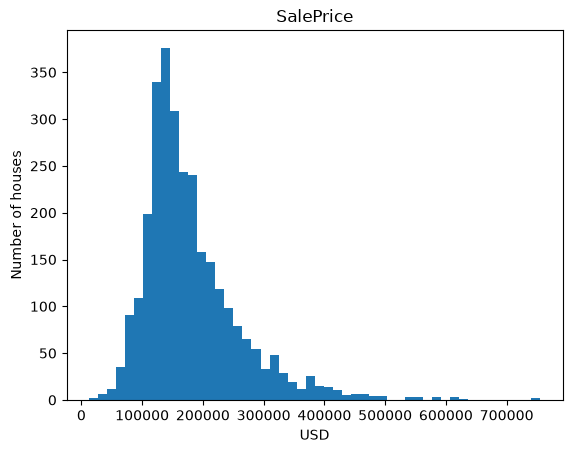

In [112]:
df["SalePrice"].plot.hist(bins=50) # each bar is a price range
plt.title("SalePrice")
plt.xlabel("USD")
plt.ylabel("Number of houses")
plt.show()

**Most houses are sold between 100,000 and 200,000 USD. We also notice that a few _very expensive_ houses push the mean (180,796 USD) higher than the median (160,000).**

---
### 1c Missing values

**The models stop at missing values, so we find where they are.**

In [113]:
missing = df.isna().sum() # Missing values per column
missing_pct = missing[missing > 0] / len(df) * 100 # Only columns with missing values, in percent.

print("Columns with missing values:", len(missing_pct))
missing_pct.sort_values(ascending=False)

Columns with missing values: 27


Pool QC          99.6
Misc Feature     96.4
Alley            93.2
Fence            80.5
Mas Vnr Type     60.6
Fireplace Qu     48.5
Lot Frontage     16.7
Garage Qual       5.4
Garage Cond       5.4
Garage Yr Blt     5.4
Garage Finish     5.4
Garage Type       5.4
Bsmt Exposure     2.8
BsmtFin Type 2    2.8
Bsmt Cond         2.7
Bsmt Qual         2.7
BsmtFin Type 1    2.7
Mas Vnr Area      0.8
Bsmt Full Bath    0.1
Bsmt Half Bath    0.1
BsmtFin SF 1      0.0
BsmtFin SF 2      0.0
Electrical        0.0
Total Bsmt SF     0.0
Bsmt Unf SF       0.0
Garage Area       0.0
Garage Cars       0.0
dtype: float64

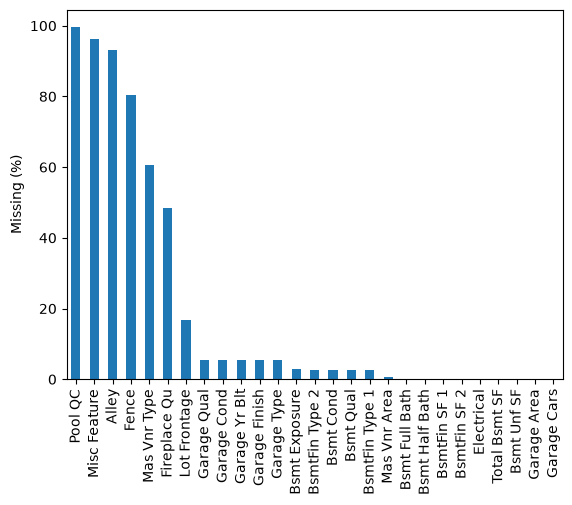

In [114]:
missing_pct.sort_values(ascending=False).plot.bar()
plt.ylabel("Missing (%)")
plt.show()

**27 columns have at least one missing value. Some are almost empty, like `Pool QC` (99.6 %), while others miss only one or two values.**

**Now, this can mean two things: Either the house doesn't have it, like no pool, or the value just wasn't recorded. We note this for step 3, where we fill them in.**

---
### 1d Unusual values or patterns

**Here we look for values that stand out or look wrong.**

In [115]:
# min and max per column
df.describe().T[["count", "min", "max"]].round()

,count,min,max
Order,2930.0,1.0,2930.0
PID,2930.0,526301100.0,1007100110.0
MS SubClass,2930.0,20.0,190.0
Lot Frontage,2440.0,21.0,313.0
Lot Area,2930.0,1300.0,215245.0
Overall Qual,2930.0,1.0,10.0
Overall Cond,2930.0,1.0,9.0
Year Built,2930.0,1872.0,2010.0
Year Remod/Add,2930.0,1950.0,2010.0
Mas Vnr Area,2907.0,0.0,1600.0


**While scanning the min and max values, we notice that the newest garage built (`Garage Yr Blt`) was built in 2207! - this has to be a typo, noting it for later.**

**Another way to spot anomalies is to look at a scatter plot. Let's take `Year Built` as an example, and check if newer houses _really_ are more expensive.**

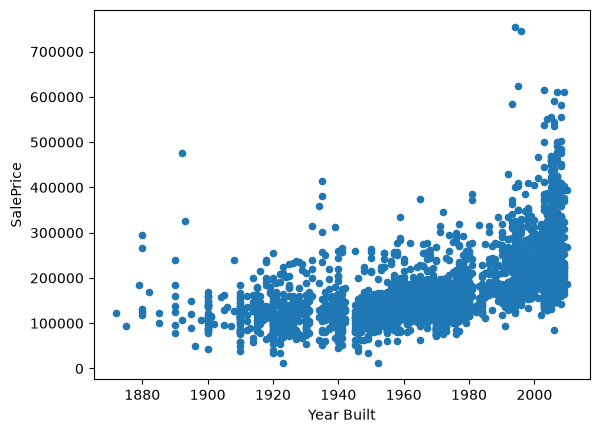

In [116]:
df.plot.scatter(x="Year Built", y="SalePrice")
plt.show()

**Three houses stand out. One built before 1900 that sold for more than 400,000, and two for more than 700,000. Let's take a closer look at them, just selecting some columns to help us see, like quality, size and neighborhood:**

In [117]:
# Old, but expensive.
df[(df["Year Built"] < 1900) & (df["SalePrice"] > 400000)][["Year Built", "SalePrice", "Overall Qual", "Gr Liv Area", "Neighborhood"]]

,Year Built,SalePrice,Overall Qual,Gr Liv Area,Neighborhood
2666,1892,475000,10,3608,OldTown


In [118]:
# Most expensive houses.
df[df["SalePrice"] > 700000][["Year Built", "SalePrice", "Overall Qual", "Gr Liv Area", "Neighborhood", "Sale Condition"]]

,Year Built,SalePrice,Overall Qual,Gr Liv Area,Neighborhood,Sale Condition
1760,1996,745000,10,4476,NoRidge,Abnorml
1767,1994,755000,10,4316,NoRidge,Normal


**All three have quality 10 and a lot of living area, so these are real houses and not errors.**

---
### 1e Relationships that may be useful for predicting house prices.

**Last, we look for columns that follow the price. Correlation can be really usefull for predicting house prices:**

In [119]:
print("Correlation with SalePrice:")
df.corr(numeric_only=True)["SalePrice"].sort_values(ascending=False)# numeric only

Correlation with SalePrice:


SalePrice          1.0
Overall Qual       0.8
Gr Liv Area        0.7
Garage Cars        0.6
Garage Area        0.6
Total Bsmt SF      0.6
1st Flr SF         0.6
Year Built         0.6
Full Bath          0.5
Year Remod/Add     0.5
Garage Yr Blt      0.5
Mas Vnr Area       0.5
TotRms AbvGrd      0.5
Fireplaces         0.5
BsmtFin SF 1       0.4
Lot Frontage       0.4
Wood Deck SF       0.3
Open Porch SF      0.3
Half Bath          0.3
Bsmt Full Bath     0.3
2nd Flr SF         0.3
Lot Area           0.3
Bsmt Unf SF        0.2
Bedroom AbvGr      0.1
Screen Porch       0.1
Pool Area          0.1
Mo Sold            0.0
3Ssn Porch         0.0
BsmtFin SF 2       0.0
Misc Val          -0.0
Yr Sold           -0.0
Order             -0.0
Bsmt Half Bath    -0.0
Low Qual Fin SF   -0.0
MS SubClass       -0.1
Overall Cond      -0.1
Kitchen AbvGr     -0.1
Enclosed Porch    -0.1
PID               -0.2
Name: SalePrice, dtype: float64

**`Overall Qual` and `Gr Liv Area` have the strongest correlation with the price, so we look closer at both.**

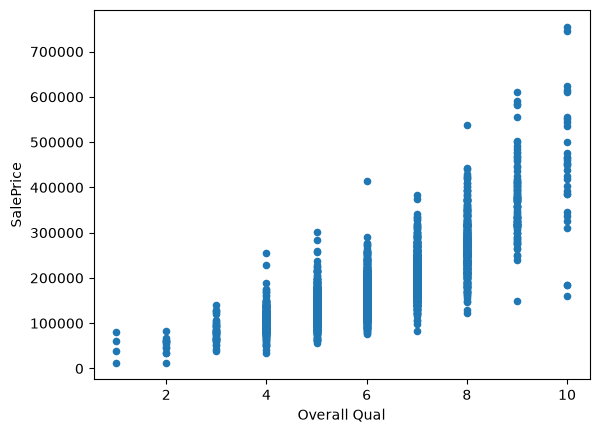

In [120]:
df.plot.scatter(x="Overall Qual", y="SalePrice")
plt.show()

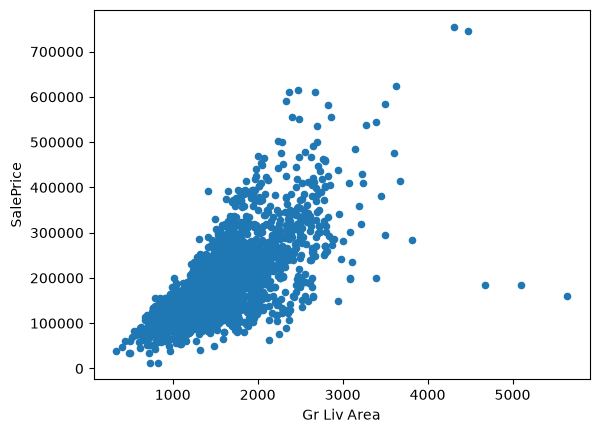

In [121]:
df.plot.scatter(x="Gr Liv Area", y="SalePrice")
plt.show()

**We can also take a look at how the house prices differ between the neighborhoods. Note: this is a text column, so it's not in the correlation list:**

In [122]:
# median price per neighborhood
print("Median neighborhood price:")
df.groupby("Neighborhood")["SalePrice"].median().sort_values() #cheapest first

Median neighborhood price:


Neighborhood
MeadowV    88250.0
BrDale    106000.0
IDOTRR    106500.0
OldTown   119900.0
Edwards   125000.0
BrkSide   126750.0
Blueste   130500.0
Sawyer    135000.0
SWISU     136200.0
Landmrk   137000.0
NAmes     140000.0
NPkVill   143750.0
Mitchel   153500.0
SawyerW   180000.0
NWAmes    181000.0
Gilbert   183000.0
Blmngtn   191500.0
ClearCr   197500.0
Greens    198000.0
CollgCr   200000.0
Crawfor   200624.0
Somerst   225500.0
Timber    232106.5
Veenker   250250.0
GrnHill   280000.0
NoRidge   302000.0
NridgHt   317750.0
StoneBr   319000.0
Name: SalePrice, dtype: float64

 **What we see is that quality and size has the strongest relationship with the price. In the `Overall Qual` plot the price climbs for every step up, but with more spread at the top levels. `Gr Liv Area` rises steadily with the price, with even more spread.**

**The median price in `Neighborhood` goes from 88,250 in MeadowV to 319,000 in StoneBr, so location matters _a lot_ and we want to keep it.**

---
## Step 2: Create training and test data

**In this step we split the list of houses (rows) into a training set and a test set, so we have some houses the model's never seen. We need two parts: `X` - a matrix we fill with everything we know about each house, and `y` - a vector with the prices:**

In [123]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["SalePrice"]) # everything except the price
y = df["SalePrice"] # the price we predict

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (2344, 81)
Test set: (586, 81)


**So 2344 houses to train on and 586 to test with. From now on we only work with the training set, with the test set not touched until step 6.**

---
## Step 3: Prepare the data

**The models can't do math on text like `NAmes`, and they stop if a value is missing. First, how much do we have to fix:**

In [124]:
print("Text columns in X_train:", len(X_train.select_dtypes(exclude="number").columns))
print("Columns with missing values:", (X_train.isna().sum() > 0).sum())

Text columns in X_train: 43
Columns with missing values: 27


**But before all that, the garage from 1d, built in 2207:**

In [125]:
X_train[X_train["Garage Yr Blt"] > 2010][["Year Built", "Garage Yr Blt", "Yr Sold"]] # garages from the future

,Year Built,Garage Yr Blt,Yr Sold
2260,2006,2207.0,2007


**Since there's no way the garage was built in the future, we set the `Garage Yr Blt` to 2007:**

In [126]:
X_train["Garage Yr Blt"] = X_train["Garage Yr Blt"].replace(2207, 2007)
X_test["Garage Yr Blt"] = X_test["Garage Yr Blt"].replace(2207, 2007) # same for test

---
### 3a Handling missing values

**The dataset guide tells us what missing means for each column. Let's start with the text columns:**

In [127]:
text_cols = X_train.select_dtypes(exclude="number").columns # same as in 1a

missing = X_train[text_cols].isna().sum()
print(missing[missing > 0].sort_values(ascending=False))

Pool QC           2332
Misc Feature      2258
Alley             2191
Fence             1868
Mas Vnr Type      1405
Fireplace Qu      1142
Garage Qual        132
Garage Finish      132
Garage Cond        132
Garage Type        130
Bsmt Exposure       71
BsmtFin Type 2      69
Bsmt Qual           68
BsmtFin Type 1      68
Bsmt Cond           68
Electrical           1
dtype: int64


**All of these are categories the houses don't have, like no pool or no alley, so they get a text-value of "None":**

In [128]:
X_train[text_cols] = X_train[text_cols].fillna("None")
X_test[text_cols] = X_test[text_cols].fillna("None")

missing = X_train[text_cols].isna().sum()
print("missing values:", len(missing[missing > 0]))

missing values: 0


**Then the numbers:**

In [129]:
num_cols = X_train.select_dtypes(include="number").columns

missing = X_train[num_cols].isna().sum()
print(missing[missing > 0].sort_values(ascending=False))

Lot Frontage      409
Garage Yr Blt     132
Mas Vnr Area       18
Bsmt Half Bath      2
Bsmt Full Bath      2
BsmtFin SF 1        1
BsmtFin SF 2        1
Total Bsmt SF       1
Bsmt Unf SF         1
Garage Cars         1
Garage Area         1
dtype: int64


**Here, because it's numerical values, the guide says the value just wasn't recorded, so we fill them with the median:**

In [130]:
medians = X_train[num_cols].median() # from the training data only

X_train[num_cols] = X_train[num_cols].fillna(medians)
X_test[num_cols] = X_test[num_cols].fillna(medians)

missing = X_train.isna().sum()
print("missing values:", len(missing[missing > 0]))

missing values: 0


---
### 3b Encoding categorical variables

**The models still can't read `NAmes` or `RL`, so the text has to become numbers.**

**To make the models understand the text, we turn the categories into true or false statements (one-hot encoding), and `pd.get_dummies()` does this for us. Every category gets its own column, with `True` for the houses in that category and `False` for the rest.**

**Some categories can end up on only one side of the split, so `reindex` gives the test set the same columns as the training set. Missing categories become 0, and categories the model never trained on are dropped:**

In [131]:
X_train = pd.get_dummies(X_train) # text becomes True/False
X_test = pd.get_dummies(X_test)

# dropping columns
for col in X_test.columns:
    if col not in X_train.columns:
        print("Only in test:", col)

# filling with 0
only_train = 0
for col in X_train.columns:
    if col not in X_test.columns:
        only_train = only_train + 1
print("Only in train:", only_train, "columns")

print("Before aligning:", X_train.shape, X_test.shape)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0) # same columns, same order

print("After aligning:", X_train.shape, X_test.shape)

Only in test: Neighborhood_Landmrk
Only in test: Roof Matl_Roll
Only in test: Exterior 2nd_Other
Only in test: Misc Feature_Elev
Only in train: 39 columns
Before aligning: (2344, 317) (586, 282)
After aligning: (2344, 317) (586, 317)


---
### 3c Scaling the numerical columns

**Because we're not training a model that measures the distance between houses, we don't have to scale. Those models adds all the columns together into one number, and the biggest column would drown out the rest.**

**Our models never add the columns together. `DecisionTreeRegressor` and `RandomForestRegressor` look at one column at a time, and only ask if a value is above or below a limit.**

---
### 3d Removing variables

**`Order` and `PID` are just labels (one value per house), so they have to go (drop). Everything else can stay until we choose features in the next step:**

In [132]:
X_train = X_train.drop(columns=["Order", "PID"]) # the two IDs from 1a
X_test = X_test.drop(columns=["Order", "PID"])

print("New columns:", X_train.shape[1]) # [0]:Rows, [1]: Columns.

New columns: 315


**The data is now ready! One-hot encoding took us from 81 (step 2) to 315 columns, only using training data of course.**

---
## Step 4 - Select and engineer features

**To find out which info is necessary, we need to check the correlation between columns and the price. Because 'get_dummies' earlier gave True/False statements instead av values, '.astype(float)' needs to be used to covert it in to floats.**

In [133]:
correlation = X_train.astype(float).corrwith(y_train) # Checks the correlation between each column in X_train and the price. (the price was split to y_train in step 2).
correlation_sorted = correlation.reindex(correlation.abs().sort_values(ascending=False).index) # Sorting the correlation in descending.
correlation_sorted # Prints the first five rows of the correlation to check.

Overall Qual        0.8
Gr Liv Area         0.7
Total Bsmt SF       0.6
Garage Cars         0.6
1st Flr SF          0.6
                   ... 
Condition 1_RRAn   -0.0
Garage Cond_Gd      0.0
Alley_Pave         -0.0
Foundation_Wood     0.0
Roof Matl_Metal    -0.0
Length: 315, dtype: float64

**Next is the plotting of the correlation to see the actual correlation.**

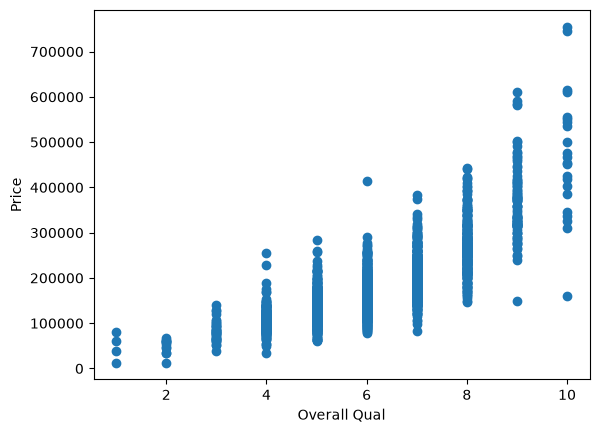

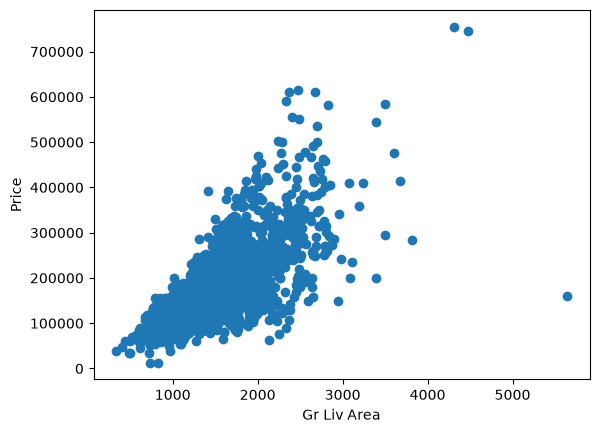

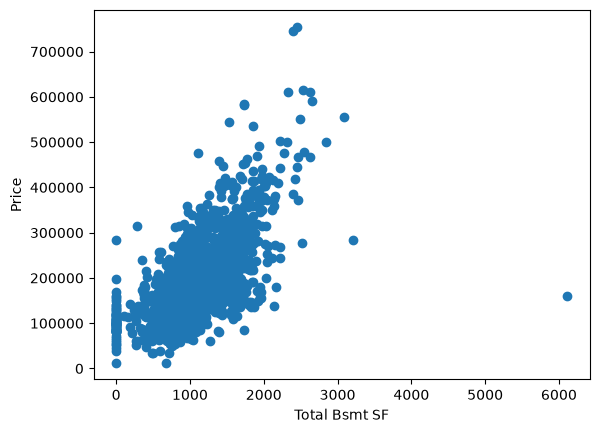

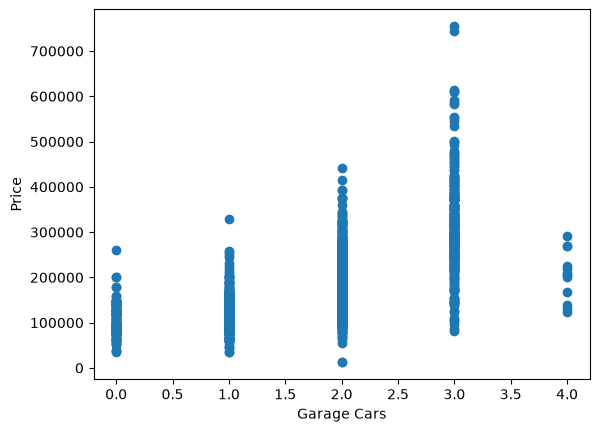

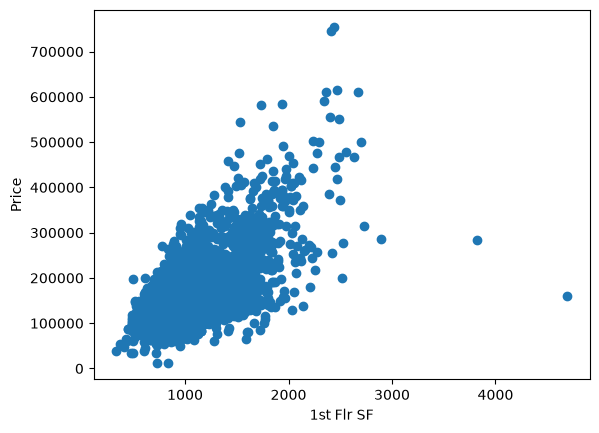

In [134]:
# Plots of the top five correlations
# Overall Qual
plt.scatter(X_train["Overall Qual"], y_train)
plt.xlabel("Overall Qual")
plt.ylabel("Price")
plt.show()

# Gr Liv Area
plt.scatter(X_train["Gr Liv Area"], y_train)
plt.xlabel("Gr Liv Area")
plt.ylabel("Price")
plt.show()

# Total Bsmt SF
plt.scatter(X_train["Total Bsmt SF"], y_train)
plt.xlabel("Total Bsmt SF")
plt.ylabel("Price")
plt.show()

# Garage Cars
plt.scatter(X_train["Garage Cars"], y_train)
plt.xlabel("Garage Cars")
plt.ylabel("Price")
plt.show()

# 1st Flr SF
plt.scatter(X_train["1st Flr SF"], y_train)
plt.xlabel("1st Flr SF")
plt.ylabel("Price")
plt.show()

**Next, columns that have almost zero and under correlation is getting removed to get rid of unnecessary data, because they are not relevant for the training data if it has no correlation with the price.**

In [135]:
no_correlation = correlation[correlation.abs() < 0.05].index  # Columns almost without correlation to the price

X_train = X_train.drop(columns=no_correlation)
X_test = X_test.drop(columns=no_correlation)  # Same columns removed from test

print("Removed:", len(no_correlation), "columns. Left:", X_train.shape[1])
X_train # Prints the new columns without the removed ones

Removed: 110 columns. Left: 205


,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,Bsmt Unf SF,...,Misc Feature_None,Misc Feature_Shed,Sale Type_COD,Sale Type_ConLD,Sale Type_New,Sale Type_WD,Sale Condition_Abnorml,Sale Condition_AdjLand,Sale Condition_Normal,Sale Condition_Partial
2073,60,97.0,10029,6,5,1988,1989,268.0,831.0,320.0,...,True,False,False,False,False,True,False,False,True,False
2754,20,86.0,11210,7,5,2005,2006,240.0,20.0,1594.0,...,True,False,False,False,True,False,False,False,False,True
1282,20,69.0,7590,5,5,1963,1963,0.0,0.0,1117.0,...,True,False,True,False,False,False,False,False,True,False
1572,20,68.0,15498,8,6,1976,1976,0.0,1165.0,0.0,...,True,False,True,False,False,False,True,False,False,False
641,90,76.0,9482,5,4,1958,1958,657.0,0.0,1866.0,...,True,False,False,False,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,90,60.0,10800,5,5,1987,1988,0.0,1200.0,0.0,...,True,False,False,False,False,True,False,False,False,False
835,20,82.0,12464,5,5,1996,1996,0.0,732.0,308.0,...,True,False,False,False,False,True,False,False,True,False
1653,60,80.0,11584,7,6,1979,1979,96.0,315.0,114.0,...,True,False,False,False,False,True,False,False,True,False
2607,80,85.0,13400,5,5,1966,1966,1047.0,516.0,380.0,...,True,False,False,False,False,True,False,False,True,False
